<a href="https://colab.research.google.com/github/manaswiluitel/class/blob/main/DAEN328FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# dataset link: https://data.cityofchicago.org/Health-Human-Services/Food-Inspections/4ijn-s7e5/about_data
# live dataset: https://data.cityofchicago.org/api/odata/v4/4ijn-s7e5

In [ ]:
import pandas as pd
import requests

In [ ]:
url = 'https://data.cityofchicago.org/api/odata/v4/4ijn-s7e5'
response = requests.get(url)

In [ ]:
data = pd.read_json(response.text)
data.head()

In [ ]:
all_data = []
top = 1000
skip = 0

while True:
    paged_url = f'https://data.cityofchicago.org/api/odata/v4/4ijn-s7e5?$top={top}&$skip={skip}'
    response = requests.get(paged_url)
    page_data = response.json().get('value', [])

    if not page_data:
        break

    all_data.extend(page_data)
    skip += top

# Convert to DataFrame
df = pd.DataFrame(all_data)
display(df.head())


# TRANSFORM

In [ ]:
new_df = df.drop(columns=['__id', 'latitude', 'longitude', 'location', 'location_address','location_city', 'location_state', 'location_zip'], inplace=True)

KeyError: "['latitude', 'longitude', 'location', 'location_address', 'location_city', 'location_state', 'location_zip'] not found in axis"

In [ ]:
new_df.head

AttributeError: 'NoneType' object has no attribute 'head'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

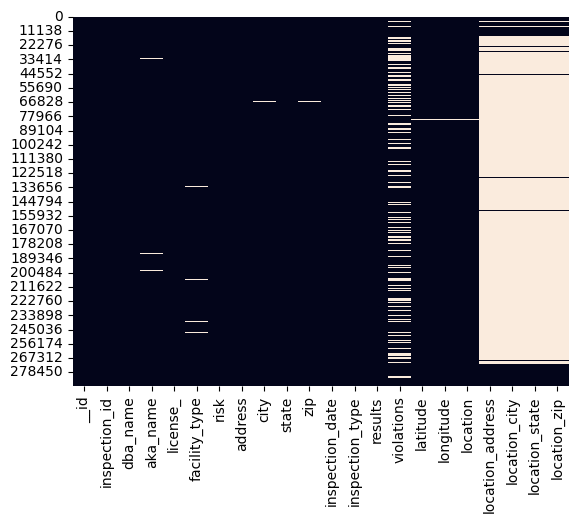

In [ ]:
# heatmap matrix showing missing values with a colorbar
sns.heatmap(df.isnull(), cbar=False, cbar_kws={'label': 'Missing Data'})
plt.show()

In [ ]:
# how many df['violations'] are null
df['violations'].isnull().sum()

np.int64(80583)

In [ ]:
(df['results'] == 'Out of Business').sum()

np.int64(24544)

In [ ]:
(df['results'] == 'Business Not Located').sum()

In [ ]:
print(df['results'].unique())

Show to fix